# Notebook 04: Fixed Effects without Location Shift - Penalty Method

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand limitations of the location shift assumption
2. Implement Koenker (2004) L1 penalized fixed effects estimator
3. Select penalty parameter $\lambda$ via cross-validation
4. Allow fixed effects to vary with quantile: $\alpha_i(\tau)$
5. Compare computational efficiency of Canay vs Penalty methods
6. Know when to use penalty method over Canay

## Duration
150 minutes

## Prerequisites
- Notebooks 01-03 (Quantile Regression Fundamentals, Multiple Quantiles, Canay FE)
- Understanding of L1 regularization concepts

## Dataset
Financial returns panel: ~200 firms over ~60 months, with stock returns, size, book-to-market, and momentum.

In [1]:
# Standard libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
import time

# Statistical libraries
from panelbox.core.panel_data import PanelData

# PanelBox imports
from panelbox.models.quantile import CanayTwoStep, FixedEffectsQuantile, PooledQuantile
from panelbox.models.quantile.comparison import FEQuantileComparison

# Visualization configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Define paths (relative to notebooks/)
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
RESULTS_DIR = OUTPUT_DIR / "results"

# Create output directories
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Setup complete!
Data directory: ../data
Output directory: ../outputs


---

## 1. Introduction & Motivation

### Research Question

> *"In financial markets, does firm-specific risk ($\alpha_i$) vary across the return distribution, or is it constant?"*

In Notebook 03, we used the **Canay (2011) two-step estimator**, which assumes that fixed effects are **pure location shifters** — the same $\alpha_i$ shifts all quantiles equally. But what if this is wrong?

### Two Models of Heterogeneity

| Model | Formulation | Assumption | Estimator |
|-------|------------|------------|----------|
| **Location Shift** | $Q_\tau(Y_{it} \mid X_{it}, \alpha_i) = \alpha_i + X_{it}'\beta(\tau)$ | $\alpha_i$ same across all $\tau$ | Canay (2011) |
| **General FE** | $Q_\tau(Y_{it} \mid X_{it}, \alpha_i) = \alpha_i(\tau) + X_{it}'\beta(\tau)$ | $\alpha_i(\tau)$ varies with $\tau$ | Koenker (2004) |

### Why Does This Matter?

Consider two firms in a financial panel:

```
Firm A (Low Risk — Symmetric):
  α_A(0.1) = -0.02  (Bad times: slightly below market)
  α_A(0.5) =  0.00  (Normal: at market)
  α_A(0.9) =  0.02  (Good times: slightly above)
  → Location shift is approximately correct

Firm B (High Risk — Asymmetric):
  α_B(0.1) = -0.10  (Bad times: much worse)
  α_B(0.5) =  0.00  (Normal: at market)
  α_B(0.9) =  0.15  (Good times: much better)
  → Location shift is WRONG. Canay misses this asymmetry.
```

The **Koenker (2004) penalty method** allows each firm's fixed effect to vary freely across quantiles, revealing this kind of asymmetric risk profile.

---

## 2. Theoretical Concepts

### 2.1 Penalty Method Formulation

The Koenker (2004) penalty method estimates the quantile regression model:

$$\min_{\beta(\tau),\, \alpha(\tau)} \sum_{i=1}^{N} \sum_{t=1}^{T} \rho_\tau\!\left(Y_{it} - \alpha_i(\tau) - X_{it}'\beta(\tau)\right) + \lambda \sum_{i=1}^{N} |\alpha_i(\tau)|$$

where:
- $\rho_\tau(u) = u(\tau - \mathbb{1}(u < 0))$ is the **check loss** (quantile objective)
- $\lambda \sum_i |\alpha_i(\tau)|$ is the **L1 penalty** on fixed effects
- $\lambda \geq 0$ is the **penalty parameter** (tuning parameter)

### Why L1 Penalty?

- **Prevents overfitting**: With $N$ entities, we have $N$ additional parameters. The L1 penalty regularizes these.
- **Sparsity**: L1 shrinks small $\alpha_i(\tau)$ exactly to zero, providing an automatic selection of "significant" fixed effects.
- **Computational feasibility**: The penalized problem can be solved via interior point methods.
- **Consistency**: Under appropriate conditions, the estimator is consistent as $N, T \to \infty$.

### 2.2 Penalty Parameter Selection

The penalty parameter $\lambda$ controls the trade-off between fit and parsimony:

```
λ = 0:   No penalty → αᵢ(τ) unconstrained (may overfit with small T)
λ → ∞:  Full penalty → αᵢ(τ) = 0 for all i (pooled QR)
λ = λ*:  Optimal trade-off between fit and parsimony
```

**Cross-Validation Procedure:**

1. Split entities into $K$ folds (entity-based splitting preserves panel structure)
2. For each $\lambda$ in a grid:
   - Fit model on $K-1$ folds
   - Predict on held-out fold
   - Compute check loss on predictions
3. Select $\lambda^*$ that minimizes average CV loss

### 2.3 Relationship Between Canay and Penalty

| Property | Canay | Penalty |
|----------|-------|--------|
| Fixed effects | $\alpha_i$ (constant) | $\alpha_i(\tau)$ (quantile-varying) |
| Estimation | 2-step: OLS → QR | Joint optimization |
| Tuning | None | $\lambda$ via CV |
| Speed | Fast | Slower |
| Flexibility | Restrictive | General |
| When to use | Location shift holds | Location shift fails |

---

## 3. Implementation

### 3.1 Data Setup

In [2]:
# Load financial returns data
data = pd.read_csv(DATA_DIR / "financial_returns.csv")

# Panel structure
print(f"Dataset shape: {data.shape}")
print(f"Variables: {data.columns.tolist()}")
print(f"Firms: {data['firm_id'].nunique()}")
print(f"Time periods: {data['month'].nunique()}")
print(f"Observations: {len(data)}")

print("\nDescriptive Statistics:")
display(data[["returns", "size", "book_to_market", "momentum"]].describe())

Dataset shape: (12000, 8)
Variables: ['firm_id', 'month', 'returns', 'size', 'book_to_market', 'momentum', 'volatility', 'sector']
Firms: 200
Time periods: 60
Observations: 12000

Descriptive Statistics:


,returns,size,book_to_market,momentum
count,12000.0000,12000.0000,12000.0000,12000.0000
mean,0.2425,8.0843,0.7168,0.0978
std,1.2938,1.9931,0.3917,0.3025
min,-7.0617,2.9930,-0.0578,-1.0343
25%,-0.5095,6.7314,0.4213,-0.1050
50%,0.2879,7.9999,0.6880,0.0985
75%,1.0292,9.2653,0.9828,0.3017
max,11.5569,14.6586,1.9777,1.2427


In [3]:
# Create PanelData object
panel = PanelData(data, entity_col="firm_id", time_col="month")
print(panel.summary())

# Formula for financial returns model
formula = "returns ~ size + book_to_market + momentum"

PANEL DATA SUMMARY
Entity identifier: firm_id
Time identifier:   month
------------------------------------------------------------
Number of entities:     200
Number of time periods: 60
Total observations:     12,000
------------------------------------------------------------
Balanced:               Yes
Periods per entity:     60
------------------------------------------------------------
Time period range:      1 to 60


### 3.2 Canay Baseline (from Notebook 03)

First, let's establish the Canay baseline and test whether the location shift assumption holds for this financial data.

In [4]:
# Canay Two-Step estimation at key quantiles
tau_list = [0.1, 0.25, 0.5, 0.75, 0.9]
canay_results = {}

print("Estimating Canay Two-Step FE-QR...")
for tau in tau_list:
    canay_model = CanayTwoStep(panel, formula=formula, tau=tau)
    canay_results[tau] = canay_model.fit(verbose=False)

# Display Canay results
canay_var_names = ["const", "size", "book_to_market", "momentum"]
print("\n" + "=" * 70)
print("CANAY TWO-STEP FE QUANTILE REGRESSION")
print("=" * 70)

print(f"{'Variable':<18}", end="")
for tau in tau_list:
    print(f"{'\u03c4=' + str(tau):>12}", end="")
print()
print("-" * 78)

for i, var in enumerate(canay_var_names):
    print(f"{var:<18}", end="")
    for tau in tau_list:
        coef = canay_results[tau].results[tau].params[i]
        print(f"{coef:12.4f}", end="")
    print()

Estimating Canay Two-Step FE-QR...



CANAY TWO-STEP FE QUANTILE REGRESSION
Variable                 τ=0.1      τ=0.25       τ=0.5      τ=0.75       τ=0.9
------------------------------------------------------------------------------
const                  -2.2898     -1.0525     -0.0057      1.0202      2.1942
size                    0.5490      0.4852      0.4366      0.3938      0.3374
book_to_market          0.2861      0.2116      0.2179      0.1637      0.1236
momentum                0.2313      0.2270      0.1975      0.2216      0.2358


In [5]:
# Test location shift assumption
canay_test = CanayTwoStep(panel, formula=formula, tau=0.5)
canay_test.fit(verbose=False)

test_result = canay_test.test_location_shift(tau_grid=[0.1, 0.25, 0.5, 0.75, 0.9], method="wald")

print(f"\nLocation shift test p-value: {test_result.p_value:.4f}")

if test_result.p_value < 0.05:
    print("\u2192 Location shift REJECTED at 5% level.")
    print("\u2192 Fixed effects likely vary across quantiles.")
    print("\u2192 Penalty method recommended.")
else:
    print("\u2192 Cannot reject location shift.")
    print("\u2192 Canay estimator is appropriate.")


Testing Location Shift Assumption
H0: Fixed effects are pure location shifters
Testing across quantiles: [0.1, 0.25, 0.5, 0.75, 0.9]
  Estimating τ = 0.1...


  Estimating τ = 0.25...
  Estimating τ = 0.5...
  Estimating τ = 0.75...
  Estimating τ = 0.9...

LOCATION SHIFT TEST RESULTS
H0: Fixed effects are pure location shifters
Method: wald
Test Statistic: 3213807.9947
Degrees of Freedom: 16
P-value: 0.0000

Conclusion: REJECT H0 at 5% level
Fixed effects appear to vary across quantiles.
Canay estimator may be biased. Consider penalty method.

Location shift test p-value: 0.0000
→ Location shift REJECTED at 5% level.
→ Fixed effects likely vary across quantiles.
→ Penalty method recommended.


### 3.3 Penalty Method with Automatic $\lambda$ Selection

Now we estimate the penalty method. When `lambda_fe='auto'`, PanelBox selects $\lambda$ via entity-based cross-validation.

In [6]:
# Penalty method with automatic lambda selection
penalty_results = {}

for tau in [0.1, 0.5, 0.9]:
    print(f"\nEstimating penalty FE-QR for \u03c4={tau}...")

    model = FixedEffectsQuantile(panel, formula=formula, tau=tau, lambda_fe="auto")
    penalty_results[tau] = model.fit(cv_folds=5, verbose=True)

    res = penalty_results[tau].results[tau]
    print(f"  Optimal \u03bb: {res.lambda_fe:.4f}")
    print(f"  Converged: {res.converged}")
    print(f"  # Zero FE: {np.sum(np.abs(res.fixed_effects) < 1e-6)}")


Estimating penalty FE-QR for τ=0.1...

Estimating Fixed Effects QR for τ = 0.1
Cross-validation for λ selection (τ=0.1)
Testing 20 values from 0.0430 to 43.0000


  λ = 0.0430: CV score = 0.207227


  λ = 0.0619: CV score = 0.207212


  λ = 0.0890: CV score = 0.207152


  λ = 0.1280: CV score = 0.207046


...

  λ = 18.1430: CV score = 0.213462


  λ = 26.0978: CV score = 0.213484


  λ = 37.5404: CV score = 0.214212


  λ = 54.0000: CV score = 0.214520
Selected λ = 0.6881 (CV score = 0.213323)


  Optimal λ: 0.6881
  Converged: True
  # Zero FE: 0


In [7]:
# Display penalty method results
print("\n" + "=" * 60)
print("PENALTY FE QUANTILE REGRESSION RESULTS")
print("=" * 60)

penalty_var_names = ["const", "size", "book_to_market", "momentum"]

for tau in [0.1, 0.5, 0.9]:
    penalty_results[tau].results[tau].summary()


PENALTY FE QUANTILE REGRESSION RESULTS

Fixed Effects Quantile Regression (τ=0.1)
Penalty parameter λ: 3.374468
Number of entities: 200
Converged: True

Coefficients:
----------------------------------------
  β1:  -4.2680 (0.0018)
  β2:   0.3641 (0.0002)
  β3:   0.3142 (0.0010)
  β4:   0.2237 (0.0014)

Fixed Effects Distribution:
----------------------------------------
  Mean:      -0.0072
  Std Dev:    0.0564
  Min:       -0.2582
  Max:        0.1762
  # Zero:   114

Fixed Effects Quantile Regression (τ=0.5)
Penalty parameter λ: 14.498791
Number of entities: 200
Converged: True

Coefficients:
----------------------------------------
  β1:  -2.0715 (0.0122)
  β2:   0.2570 (0.0013)
  β3:   0.2806 (0.0066)
  β4:   0.1920 (0.0065)

Fixed Effects Distribution:
----------------------------------------
  Mean:      -0.0004
  Std Dev:    0.0032
  Min:       -0.0350
  Max:        0.0054
  # Zero:   100

Fixed Effects Quantile Regression (τ=0.9)
Penalty parameter λ: 0.688108
Number of entiti

### 3.4 Manual $\lambda$ Selection (Grid Search)

To understand how $\lambda$ selection works, let's manually search over a grid and plot the CV curve.

In [8]:
# Manual lambda grid search at the median
tau = 0.5
lambda_grid = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

manual_results = {}
objective_values = []

print("Manual \u03bb grid search (\u03c4=0.5):")
print("-" * 50)

for lam in lambda_grid:
    model = FixedEffectsQuantile(panel, formula=formula, tau=tau, lambda_fe=lam)
    result = model.fit(verbose=False)
    res = result.results[tau]

    # Compute objective value (check loss on full data)
    alpha_expanded = res.fixed_effects[model.obs_to_entity]
    residuals = model.y - model.X @ res.params - alpha_expanded
    check_loss = np.mean(model.check_loss(residuals, tau))

    n_zero = np.sum(np.abs(res.fixed_effects) < 1e-6)
    manual_results[lam] = result
    objective_values.append(check_loss)

    print(
        f"\u03bb={lam:8.3f}: Check Loss = {check_loss:.4f}, "
        f"# Zero FE = {n_zero:3d}/{len(res.fixed_effects)}"
    )

Manual λ grid search (τ=0.5):
--------------------------------------------------


λ=   0.001: Check Loss = 0.4235, # Zero FE =   0/200


λ=   0.010: Check Loss = 0.4235, # Zero FE =   0/200


λ=   0.100: Check Loss = 0.4235, # Zero FE =   0/200


λ=   1.000: Check Loss = 0.4237, # Zero FE =   0/200


λ=  10.000: Check Loss = 0.4328, # Zero FE = 140/200


λ= 100.000: Check Loss = 0.4340, # Zero FE = 153/200


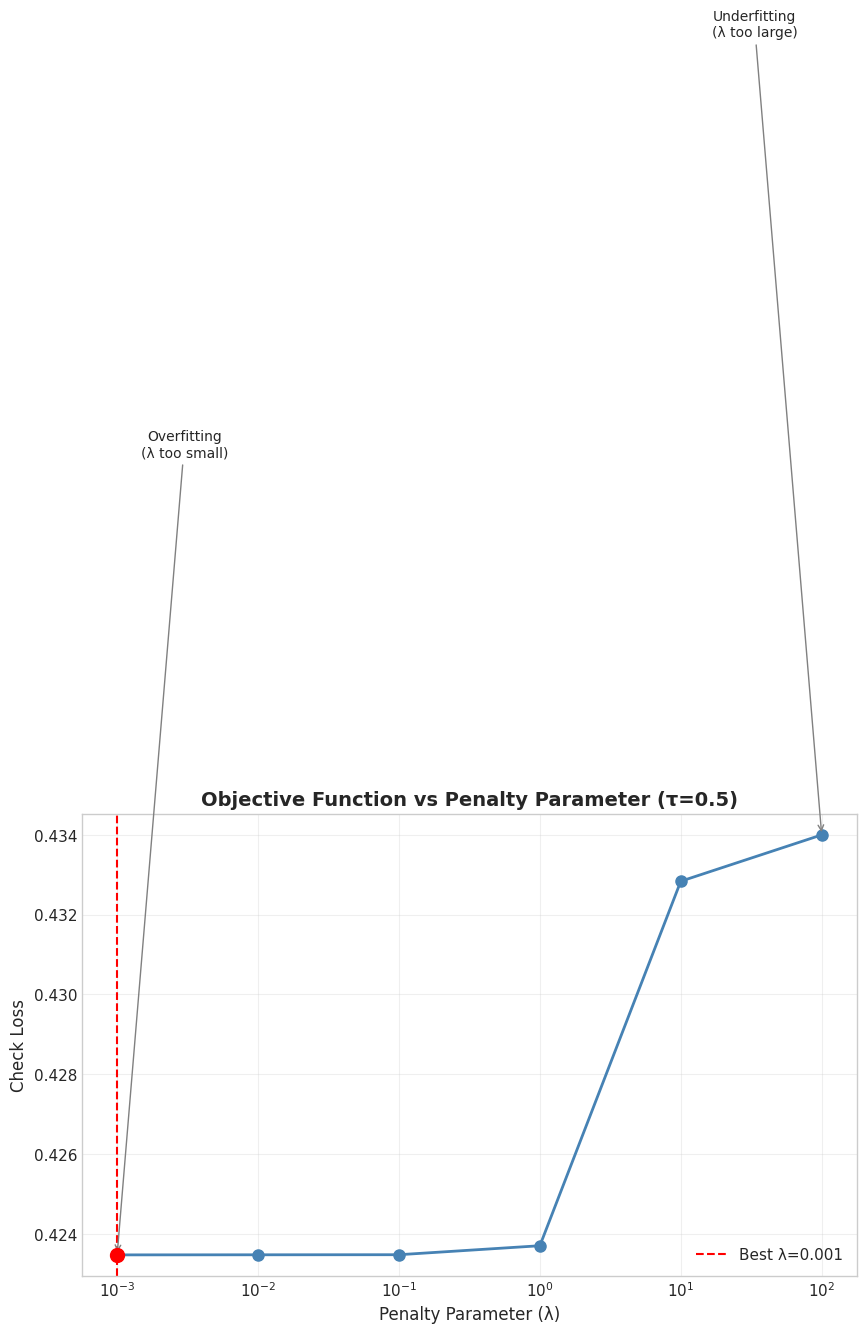

Plot saved to ../outputs/plots/04_cv_lambda.png


In [9]:
# Plot CV / objective curve
fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogx(lambda_grid, objective_values, "o-", linewidth=2, markersize=8, color="steelblue")
ax.set_xlabel("Penalty Parameter (\u03bb)", fontsize=12)
ax.set_ylabel("Check Loss", fontsize=12)
ax.set_title("Objective Function vs Penalty Parameter (\u03c4=0.5)", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)

# Mark the minimum
best_idx = np.argmin(objective_values)
ax.axvline(
    lambda_grid[best_idx],
    color="red",
    linestyle="--",
    label=f"Best \u03bb={lambda_grid[best_idx]:.3f}",
)
ax.scatter([lambda_grid[best_idx]], [objective_values[best_idx]], color="red", s=100, zorder=5)

# Annotate regions
ax.annotate(
    "Overfitting\n(\u03bb too small)",
    xy=(lambda_grid[0], objective_values[0]),
    xytext=(lambda_grid[0] * 3, objective_values[0] + 0.02),
    fontsize=10,
    ha="center",
    arrowprops={"arrowstyle": "->", "color": "gray"},
)
ax.annotate(
    "Underfitting\n(\u03bb too large)",
    xy=(lambda_grid[-1], objective_values[-1]),
    xytext=(lambda_grid[-1] / 3, objective_values[-1] + 0.02),
    fontsize=10,
    ha="center",
    arrowprops={"arrowstyle": "->", "color": "gray"},
)

ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_cv_lambda.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot saved to {PLOTS_DIR / '04_cv_lambda.png'}")

*Figure: The check loss as a function of the penalty parameter $\lambda$. Small $\lambda$ allows overfitting (too many free parameters), while large $\lambda$ forces all fixed effects to zero (underfitting). The optimal $\lambda$ balances these two extremes.*

> **Key Insight**  
> The curve has a U-shape (or near-U). At the optimum, the penalty is just strong enough to regularize the fixed effects without eliminating meaningful heterogeneity.

### 3.5 Extract and Compare Fixed Effects Across Quantiles

The key advantage of the penalty method is that we can examine how each firm's fixed effect varies across quantiles. Under the Canay model, $\alpha_i$ would be the same at all quantiles.

In [10]:
# Compare fixed effects across quantiles
n_firms_show = 20
unique_firms = data["firm_id"].unique()[:n_firms_show]

alpha_comparison = pd.DataFrame(index=range(n_firms_show))
alpha_comparison["firm_id"] = unique_firms

for tau in [0.1, 0.5, 0.9]:
    res = penalty_results[tau].results[tau]
    # Map firm indices to fixed effects
    # The model stores entity_map: entity_id -> index
    model_obj = res.model
    alphas = []
    for firm in unique_firms:
        if firm in model_obj.entity_map:
            idx = model_obj.entity_map[firm]
            alphas.append(res.fixed_effects[idx])
        else:
            alphas.append(0.0)
    alpha_comparison[f"alpha_{int(100 * tau)}"] = alphas

print("Fixed Effects for First 20 Firms:")
display(alpha_comparison.set_index("firm_id").round(4))

Fixed Effects for First 20 Firms:


,alpha_10,alpha_50,alpha_90
firm_id,,,
1,-0.0000,0.0008,-0.1308
2,-0.0000,0.0000,0.2198
3,0.1762,0.0000,0.3212
4,-0.0000,-0.0003,-0.1519
5,0.0000,-0.0000,0.0384
6,-0.0001,-0.0003,-0.3470
7,0.0382,0.0000,-0.1501
8,0.0947,0.0046,0.4785
9,0.0000,-0.0000,-0.1485


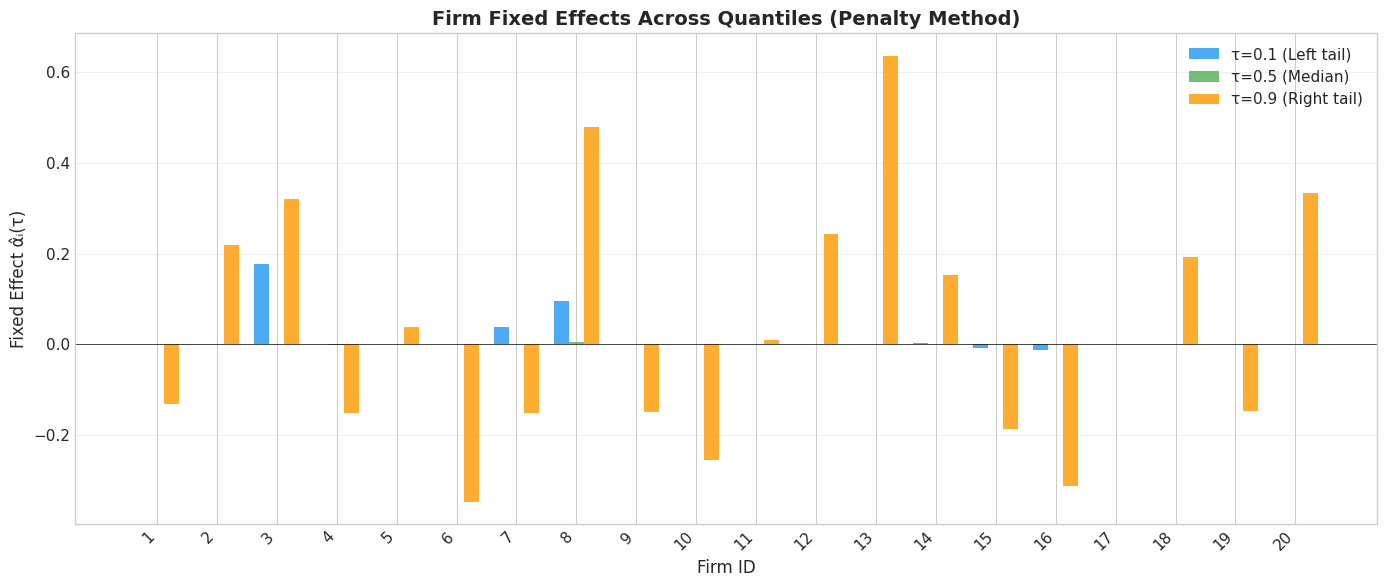

Plot saved to ../outputs/plots/04_fixed_effects_quantiles.png


In [11]:
# Visualize fixed effects across quantiles
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(n_firms_show)
width = 0.25

bars1 = ax.bar(
    x - width,
    alpha_comparison["alpha_10"],
    width,
    label="\u03c4=0.1 (Left tail)",
    color="#2196F3",
    alpha=0.8,
)
bars2 = ax.bar(
    x, alpha_comparison["alpha_50"], width, label="\u03c4=0.5 (Median)", color="#4CAF50", alpha=0.8
)
bars3 = ax.bar(
    x + width,
    alpha_comparison["alpha_90"],
    width,
    label="\u03c4=0.9 (Right tail)",
    color="#FF9800",
    alpha=0.8,
)

ax.set_xlabel("Firm ID", fontsize=12)
ax.set_ylabel("Fixed Effect \u03b1\u0302\u1d62(\u03c4)", fontsize=12)
ax.set_title("Firm Fixed Effects Across Quantiles (Penalty Method)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(unique_firms, rotation=45, ha="right")
ax.legend(fontsize=11)
ax.axhline(0, color="black", linewidth=0.5)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_fixed_effects_quantiles.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot saved to {PLOTS_DIR / '04_fixed_effects_quantiles.png'}")

In [12]:
# Test if fixed effects vary significantly across quantiles
print("\nTesting \u03b1\u1d62(\u03c4) heterogeneity:")
print("=" * 50)

corr_10_50 = alpha_comparison["alpha_10"].corr(alpha_comparison["alpha_50"])
corr_50_90 = alpha_comparison["alpha_50"].corr(alpha_comparison["alpha_90"])
corr_10_90 = alpha_comparison["alpha_10"].corr(alpha_comparison["alpha_90"])

print(f"Correlation \u03b1(0.1) vs \u03b1(0.5): {corr_10_50:.3f}")
print(f"Correlation \u03b1(0.5) vs \u03b1(0.9): {corr_50_90:.3f}")
print(f"Correlation \u03b1(0.1) vs \u03b1(0.9): {corr_10_90:.3f}")

# Interpretation
if corr_10_50 < 0.9 or corr_50_90 < 0.9:
    print("\n\u2192 Fixed effects VARY significantly across quantiles.")
    print("\u2192 The penalty method captures this heterogeneity.")
    print("\u2192 Canay's location shift assumption would miss it.")
else:
    print("\n\u2192 Fixed effects are fairly similar across quantiles.")
    print("\u2192 Location shift is a reasonable approximation.")


Testing αᵢ(τ) heterogeneity:
Correlation α(0.1) vs α(0.5): 0.415
Correlation α(0.5) vs α(0.9): 0.378
Correlation α(0.1) vs α(0.9): 0.393

→ Fixed effects VARY significantly across quantiles.
→ The penalty method captures this heterogeneity.
→ Canay's location shift assumption would miss it.


---

## 4. Case Study: Financial Risk Heterogeneity

### Research Question
> *Do high-risk and low-risk firms have different sensitivity to market factors across return quantiles?*

### 4.1 Classifying Firms by Risk Profile

In [13]:
# Classify firms by their FE spread across quantiles
# FE spread = alpha(0.9) - alpha(0.1) measures asymmetry

# Get all firm fixed effects
all_firms = data["firm_id"].unique()

firm_profiles = pd.DataFrame(index=all_firms)
for tau in [0.1, 0.5, 0.9]:
    res = penalty_results[tau].results[tau]
    model_obj = res.model
    alphas = []
    for firm in all_firms:
        if firm in model_obj.entity_map:
            idx = model_obj.entity_map[firm]
            alphas.append(res.fixed_effects[idx])
        else:
            alphas.append(0.0)
    firm_profiles[f"alpha_{int(100 * tau)}"] = alphas

firm_profiles["fe_spread"] = firm_profiles["alpha_90"] - firm_profiles["alpha_10"]
firm_profiles["fe_mean"] = firm_profiles[["alpha_10", "alpha_50", "alpha_90"]].mean(axis=1)

# Classify: top/bottom quartile of spread
q25 = firm_profiles["fe_spread"].quantile(0.25)
q75 = firm_profiles["fe_spread"].quantile(0.75)
firm_profiles["risk_type"] = "Medium"
firm_profiles.loc[firm_profiles["fe_spread"] <= q25, "risk_type"] = "Symmetric (Low spread)"
firm_profiles.loc[firm_profiles["fe_spread"] >= q75, "risk_type"] = "Asymmetric (High spread)"

print("Firm Risk Classification:")
print(firm_profiles["risk_type"].value_counts())

print("\nFE Spread Distribution:")
print(firm_profiles["fe_spread"].describe())

Firm Risk Classification:
risk_type
Medium                      100
Asymmetric (High spread)     50
Symmetric (Low spread)       50
Name: count, dtype: int64

FE Spread Distribution:
count    2.0000e+02
mean     1.3457e-02
std      2.5474e-01
min     -6.0421e-01
25%     -1.4705e-01
50%      7.4382e-05
75%      1.3214e-01
max      7.7474e-01
Name: fe_spread, dtype: float64


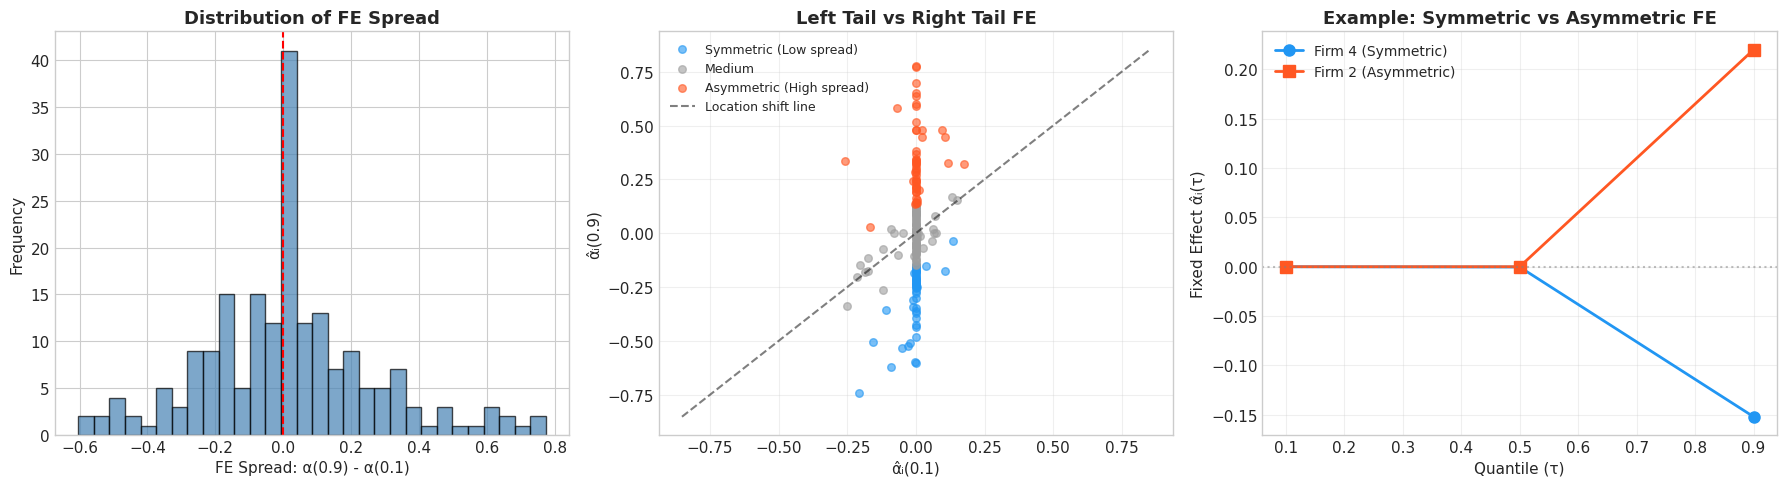

In [14]:
# Visualize risk profiles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: FE spread distribution
axes[0].hist(firm_profiles["fe_spread"], bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("FE Spread: \u03b1(0.9) - \u03b1(0.1)", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].set_title("Distribution of FE Spread", fontsize=13, fontweight="bold")

# Plot 2: alpha(0.1) vs alpha(0.9) scatter
colors = {
    "Symmetric (Low spread)": "#2196F3",
    "Medium": "#9E9E9E",
    "Asymmetric (High spread)": "#FF5722",
}
for rtype, color in colors.items():
    mask = firm_profiles["risk_type"] == rtype
    axes[1].scatter(
        firm_profiles.loc[mask, "alpha_10"],
        firm_profiles.loc[mask, "alpha_90"],
        c=color,
        label=rtype,
        alpha=0.6,
        s=30,
    )
# 45-degree line (location shift would put all points on this line)
lim = (
    max(
        abs(firm_profiles["alpha_10"].min()),
        abs(firm_profiles["alpha_90"].max()),
        abs(firm_profiles["alpha_10"].max()),
        abs(firm_profiles["alpha_90"].min()),
    )
    * 1.1
)
axes[1].plot([-lim, lim], [-lim, lim], "k--", alpha=0.5, label="Location shift line")
axes[1].set_xlabel("\u03b1\u0302\u1d62(0.1)", fontsize=11)
axes[1].set_ylabel("\u03b1\u0302\u1d62(0.9)", fontsize=11)
axes[1].set_title("Left Tail vs Right Tail FE", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Plot 3: Example firms
# Pick one symmetric and one asymmetric firm
symmetric_firm = firm_profiles[firm_profiles["risk_type"] == "Symmetric (Low spread)"].index[0]
asymmetric_firm = firm_profiles[firm_profiles["risk_type"] == "Asymmetric (High spread)"].index[0]

taus_plot = [0.1, 0.5, 0.9]
sym_alphas = [firm_profiles.loc[symmetric_firm, f"alpha_{int(100 * t)}"] for t in taus_plot]
asym_alphas = [firm_profiles.loc[asymmetric_firm, f"alpha_{int(100 * t)}"] for t in taus_plot]

axes[2].plot(
    taus_plot,
    sym_alphas,
    "o-",
    linewidth=2,
    markersize=8,
    label=f"Firm {symmetric_firm} (Symmetric)",
    color="#2196F3",
)
axes[2].plot(
    taus_plot,
    asym_alphas,
    "s-",
    linewidth=2,
    markersize=8,
    label=f"Firm {asymmetric_firm} (Asymmetric)",
    color="#FF5722",
)
axes[2].axhline(0, color="gray", linestyle=":", alpha=0.5)
axes[2].set_xlabel("Quantile (\u03c4)", fontsize=11)
axes[2].set_ylabel("Fixed Effect \u03b1\u0302\u1d62(\u03c4)", fontsize=11)
axes[2].set_title("Example: Symmetric vs Asymmetric FE", fontsize=13, fontweight="bold")
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 Comparing Slope Coefficients: Canay vs Penalty

In [15]:
# Coefficient comparison: Canay vs Penalty
print("=" * 80)
print("COEFFICIENT COMPARISON: CANAY vs PENALTY")
print("=" * 80)

comparison_rows = []
for tau in [0.1, 0.5, 0.9]:
    canay_params = canay_results[tau].results[tau].params
    penalty_params = penalty_results[tau].results[tau].params

    for i, var in enumerate(canay_var_names):
        comparison_rows.append(
            {
                "tau": tau,
                "variable": var,
                "canay": canay_params[i],
                "penalty": penalty_params[i],
                "difference": penalty_params[i] - canay_params[i],
            }
        )

comp_df = pd.DataFrame(comparison_rows)
display(
    comp_df.pivot_table(index=["variable", "tau"], values=["canay", "penalty", "difference"]).round(
        4
    )
)

COEFFICIENT COMPARISON: CANAY vs PENALTY


canay  difference  penalty
variable       tau                             
book_to_market 0.1  0.2861      0.0281   0.3142
               0.5  0.2179      0.0627   0.2806
               0.9  0.1236      0.0774   0.2010
const          0.1 -2.2898     -1.9782  -4.2680
               0.5 -0.0057     -2.0658  -2.0715
               0.9  2.1942     -2.0103   0.1839
momentum       0.1  0.2313     -0.0077   0.2237
               0.5  0.1975     -0.0055   0.1920
               0.9  0.2358      0.0213   0.2571
size           0.1  0.5490     -0.1850   0.3641
               0.5  0.4366     -0.1795   0.2570
               0.9  0.3374     -0.1855   0.1519

> **Interpretation**  
> If the slope coefficients from Canay and penalty are similar, then the location shift violation affects mainly the fixed effects (not the slopes). If they differ substantially, the location shift violation also biases the slope estimates in the Canay model.

---

## 5. Computational Comparison

The penalty method is more flexible but computationally more expensive. Let's benchmark the different methods.

In [16]:
# Benchmark timing for different methods
np.random.seed(42)

# Prepare arrays for PooledQuantile
y = data["returns"].values
X = np.column_stack(
    [
        np.ones(len(data)),
        data["size"].values,
        data["book_to_market"].values,
        data["momentum"].values,
    ]
)
entity_id = data["firm_id"].values

timing_results = {}

# 1. Pooled QR
print("Benchmarking methods...")
start = time.time()
pooled_model = PooledQuantile(y, X, entity_id=entity_id, quantiles=0.5)
pooled_result = pooled_model.fit(se_type="cluster")
timing_results["Pooled QR"] = time.time() - start
print(f"  Pooled QR:           {timing_results['Pooled QR']:.2f}s")

# 2. Canay Two-Step
start = time.time()
canay_model = CanayTwoStep(panel, formula=formula, tau=0.5)
canay_result = canay_model.fit(verbose=False)
timing_results["Canay"] = time.time() - start
print(f"  Canay Two-Step:      {timing_results['Canay']:.2f}s")

# 3. Penalty with fixed lambda
start = time.time()
penalty_model = FixedEffectsQuantile(panel, formula=formula, tau=0.5, lambda_fe=1.0)
penalty_result = penalty_model.fit(verbose=False)
timing_results["Penalty (\u03bb=1)"] = time.time() - start
print(f"  Penalty (\u03bb=1):      {timing_results['Penalty (\u03bb=1)']:.2f}s")

# 4. Penalty with CV
start = time.time()
penalty_cv_model = FixedEffectsQuantile(panel, formula=formula, tau=0.5, lambda_fe="auto")
penalty_cv_result = penalty_cv_model.fit(cv_folds=3, verbose=False)
timing_results["Penalty (CV)"] = time.time() - start
print(f"  Penalty (CV):        {timing_results['Penalty (CV)']:.2f}s")

print("\nDone!")

Benchmarking methods...
  Pooled QR:           0.02s


  Canay Two-Step:      0.22s


  Penalty (λ=1):      0.98s


  Penalty (CV):        40.03s

Done!


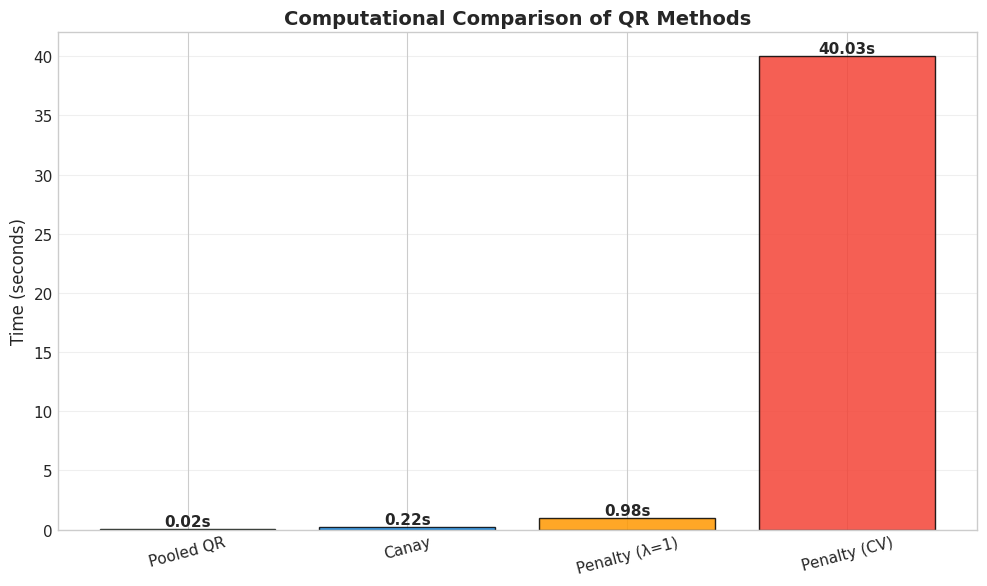

Plot saved to ../outputs/plots/04_timing_comparison.png


In [17]:
# Visualize timing comparison
fig, ax = plt.subplots(figsize=(10, 6))

methods = list(timing_results.keys())
times = list(timing_results.values())
colors_bar = ["#4CAF50", "#2196F3", "#FF9800", "#F44336"]

bars = ax.bar(methods, times, color=colors_bar, edgecolor="black", alpha=0.85)

# Add time labels on bars
for bar, t in zip(bars, times):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.01,
        f"{t:.2f}s",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_ylabel("Time (seconds)", fontsize=12)
ax.set_title("Computational Comparison of QR Methods", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_timing_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot saved to {PLOTS_DIR / '04_timing_comparison.png'}")

> **Computational Trade-offs**
>
> | Method | Speed | Fixed Effects | Tuning |
> |--------|-------|--------------|--------|
> | Pooled QR | Fastest | None | None |
> | Canay | Fast | Constant $\alpha_i$ | None |
> | Penalty ($\lambda$ fixed) | Moderate | Quantile-varying $\alpha_i(\tau)$ | Manual |
> | Penalty (CV) | Slowest | Quantile-varying $\alpha_i(\tau)$ | Automatic |
>
> **Recommendations:**
> - $N < 100$: Penalty with CV is fine
> - $100 < N < 1000$: Use Canay if location shift holds; otherwise penalty with fixed $\lambda$
> - $N > 1000$: Use Canay if possible; penalty may be slow
> - Always start with Canay + location shift test to decide

---

## 6. Using `FEQuantileComparison` for Systematic Comparison

PanelBox provides a convenient comparison class that runs all methods and summarizes results.

In [18]:
# Systematic comparison using FEQuantileComparison
comparison = FEQuantileComparison(panel, formula=formula, tau=0.5)
comp_results = comparison.compare_all(methods=["pooled", "canay", "penalty"], verbose=True)


COMPARING FIXED EFFECTS QR ESTIMATORS

1. Pooled Quantile Regression
----------------------------------------
  Time: 0.02 seconds
  Pseudo-R²: 0.1106

2. Canay Two-Step Estimator
----------------------------------------

Testing Location Shift Assumption
H0: Fixed effects are pure location shifters
Testing across quantiles: [0.1, 0.25, 0.5, 0.75, 0.9]
  Estimating τ = 0.1...


  Estimating τ = 0.25...
  Estimating τ = 0.5...
  Estimating τ = 0.75...
  Estimating τ = 0.9...

LOCATION SHIFT TEST RESULTS
H0: Fixed effects are pure location shifters
Method: wald
Test Statistic: 3213807.9947
Degrees of Freedom: 16
P-value: 0.0000

Conclusion: REJECT H0 at 5% level
Fixed effects appear to vary across quantiles.
Canay estimator may be biased. Consider penalty method.
  Time: 0.10 seconds
  Location shift p-value: 0.0000

3. Koenker Penalty Method
----------------------------------------


  Time: 83.81 seconds
  Optimal λ: 14.4988
  Zero FE: 100


COEFFICIENT ESTIMATES
------------------------------------------------------------
Coef        pooled       canay     penalty
------------------------------------------
β1          -2.0680     -0.0057     -2.0715
β2           0.2570      0.4366      0.2570
β3           0.2781      0.2179      0.2806
β4           0.1928      0.1975      0.1920

COMPUTATIONAL TIME (seconds)
----------------------------------------
pooled                0.02
canay                 0.10
penalty              83.81

Fastest: pooled

DIAGNOSTICS
----------------------------------------

pooled:
  pseudo_r2: 0.1106

canay:
  pseudo_r2: 0.2420
  location_shift_pval: 0.0000

penalty:
  pseudo_r2: 0.1106
  lambda_optimal: 14.4988
  n_zero_fe: 100


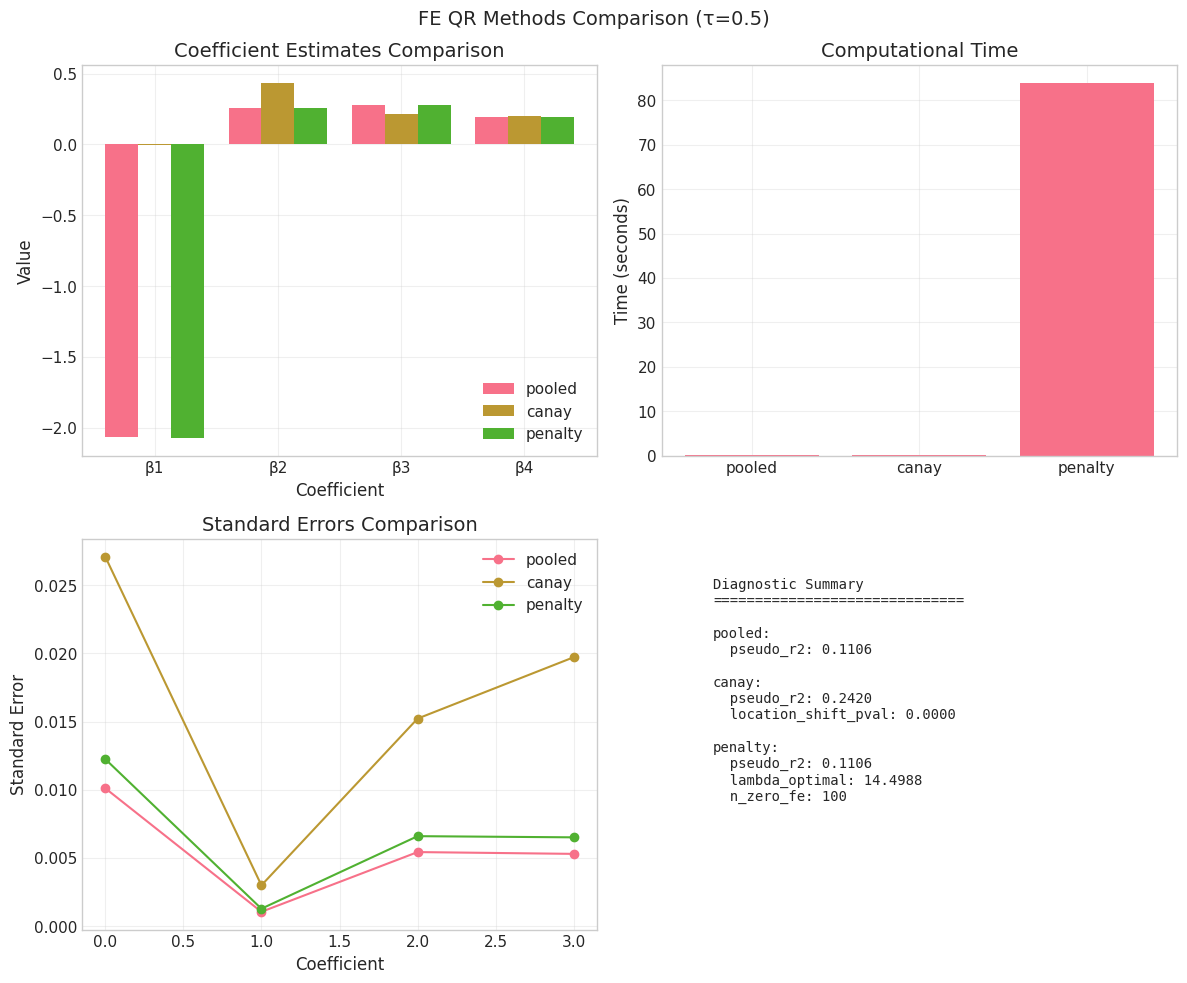

In [19]:
# Visualize the comparison
fig = comp_results.plot_comparison()
plt.show()

---

## 7. Saving Results

In [20]:
# Save penalty results to CSV
results_rows = []
for tau in [0.1, 0.5, 0.9]:
    res = penalty_results[tau].results[tau]
    var_names = ["const", "size", "book_to_market", "momentum"]
    for i, var in enumerate(var_names):
        results_rows.append(
            {
                "tau": tau,
                "variable": var,
                "coefficient": res.params[i],
                "std_error": res.bse[i],
                "lambda_optimal": res.lambda_fe,
                "converged": res.converged,
                "n_zero_fe": int(np.sum(np.abs(res.fixed_effects) < 1e-6)),
                "n_entities": len(res.fixed_effects),
            }
        )

results_df = pd.DataFrame(results_rows)
results_df.to_csv(RESULTS_DIR / "04_penalty_results.csv", index=False)

print("Results saved to outputs/results/04_penalty_results.csv")
display(results_df)

Results saved to outputs/results/04_penalty_results.csv


,tau,variable,coefficient,std_error,lambda_optimal,converged,n_zero_fe,n_entities
0,0.1,const,-4.2680,1.7721e-03,3.3745,True,114,200
1,0.1,size,0.3641,1.9759e-04,3.3745,True,114,200
2,0.1,book_to_market,0.3142,9.6689e-04,3.3745,True,114,200
3,0.1,momentum,0.2237,1.3837e-03,3.3745,True,114,200
4,0.5,const,-2.0715,1.2249e-02,14.4988,True,100,200
5,0.5,size,0.2570,1.2760e-03,14.4988,True,100,200
6,0.5,book_to_market,0.2806,6.5942e-03,14.4988,True,100,200
7,0.5,momentum,0.1920,6.5080e-03,14.4988,True,100,200
8,0.9,const,0.1839,7.2921e-04,0.6881,True,0,200
9,0.9,size,0.1519,7.8534e-05,0.6881,True,0,200


---

## 8. Decision Guide: Canay vs Penalty

### Decision Tree

```
Fixed effects panel QR needed?
  |
  +-- Step 1: Test location shift
  |     |
  |     +-- ACCEPT (p > 0.05)
  |     |     +-- Use CANAY (simpler, faster, more efficient)
  |     |
  |     +-- REJECT (p < 0.05)
  |           +-- Use PENALTY (more flexible)
  |
  +-- Step 2: Check sample size
  |     |
  |     +-- N < 500 --> Penalty is feasible
  |     +-- N > 1000 --> Penalty may be slow, consider:
  |           - Fixed lambda (no CV)
  |           - Subsampling
  |
  +-- Step 3: Theory
        |
        +-- Theory suggests alpha_i constant --> Canay
        +-- Theory suggests alpha_i(tau) varies --> Penalty
```

### When to Use Each Method

**USE PENALTY METHOD WHEN:**
- Location shift test rejects
- Theory suggests quantile-varying FE (e.g., risk models in finance)
- Sample size manageable ($N < 1000$)
- $\alpha_i(\tau)$ patterns are of substantive interest
- Computational resources available

**USE CANAY INSTEAD WHEN:**
- Location shift holds (more efficient estimates)
- $N$ is very large and computational constraints bind
- Only interested in $\beta(\tau)$, not $\alpha_i(\tau)$
- Panel is very short ($T < 3$)

---

## 9. Summary and Key Takeaways

1. **Location shift limitation**: The Canay estimator assumes $\alpha_i$ is the same across all quantiles. If this fails, the penalty method is needed.

2. **Koenker (2004) penalty method**: Adds an L1 penalty $\lambda \sum_i |\alpha_i(\tau)|$ to the quantile objective. This allows $\alpha_i(\tau)$ to vary freely while regularizing to prevent overfitting.

3. **$\lambda$ selection**: The penalty parameter balances fit and parsimony. Cross-validation provides automatic selection, but manual grids help build intuition.

4. **Quantile-varying FE**: The penalty method reveals how firm-specific effects change across the return distribution, distinguishing symmetric vs asymmetric risk profiles.

5. **Computational cost**: The penalty method is slower than Canay (iterative optimization vs two simple steps), especially with CV for $\lambda$ selection.

6. **Decision framework**: Always start with Canay + location shift test. Use penalty only when the test rejects and/or theory suggests quantile-varying FE.

### References

1. **Koenker, R. (2004)**. "Quantile Regression for Longitudinal Data". *Journal of Multivariate Analysis*, 91(1), 74-89.
2. **Lamarche, C. (2010)**. "Robust Penalized Quantile Regression Estimation for Panel Data". *Journal of Econometrics*, 157(2), 396-408.
3. **Kato, K., Galvao, A. F., & Montes-Rojas, G. V. (2012)**. "Asymptotics for Panel Quantile Regression Models with Individual Effects". *Journal of Econometrics*, 170(1), 76-91.

### Next Steps

In **Notebook 05**, we will explore the **Location-Scale Model**, which provides a parametric decomposition of how covariates affect both the location and scale of the conditional distribution.

---

## Exercises

### Exercise 1: L1 vs L2 Penalty (Easy)

**Question**: Why does the Koenker penalty use L1 (Lasso) instead of L2 (Ridge) for the fixed effects? Consider the following properties:

- Sparsity (setting some $\alpha_i$ exactly to zero)
- Bias of the estimator
- Computational tractability
- Behavior with many entities

Write your answer as markdown/comments and provide a simple numerical demonstration.

In [21]:
# Exercise 1: L1 vs L2 penalty properties

# TODO: Explain in comments why L1 is preferred over L2
# Consider: sparsity, bias, computation

# TODO: Demonstrate the sparsity property of L1
# Hint: Fit with different lambda values and count how many FE are zero


### Exercise 2: Manual Cross-Validation (Easy)

**Task**: Implement a manual entity-based cross-validation loop for $\lambda$ selection. Compare with the automatic result from `lambda_fe='auto'`.

**Steps**:
1. Define a lambda grid: `[0.001, 0.01, 0.1, 1, 10, 100]`
2. Split firms into 3 folds
3. For each lambda, fit on 2 folds and evaluate check loss on the held-out fold
4. Select the lambda with minimum average CV loss

In [22]:
# Exercise 2: Manual cross-validation

# TODO: Define lambda grid
# TODO: Split firms into K folds
# TODO: Loop over lambdas and folds
# TODO: Compute CV scores
# TODO: Compare with automatic selection


### Exercise 3: Lambda Extremes (Medium)

**Task**: Show empirically that:
- $\lambda = 0$ gives unconstrained FE (large variance)
- $\lambda \to \infty$ gives pooled QR (all FE = 0)

**Steps**:
1. Fit the penalty model with `lambda_fe=0.001` (near-zero)
2. Fit with `lambda_fe=1000` (very large)
3. Compare the resulting FE distributions and slope coefficients with pooled QR

In [23]:
# Exercise 3: Lambda extremes

# TODO: Fit with near-zero lambda
# TODO: Fit with very large lambda
# TODO: Fit pooled QR for comparison
# TODO: Compare FE distributions (histogram)
# TODO: Compare slope coefficients


### Exercise 4: FE Scatter Plot (Medium)

**Task**: Create a scatter plot of $\hat{\alpha}_i(0.1)$ vs $\hat{\alpha}_i(0.9)$ for **all** firms (not just 20). Add the 45-degree line and compute the correlation.

**Questions**:
1. What does the correlation tell us about the location shift assumption?
2. Are there firms far from the 45-degree line? What does that mean?
3. Is the correlation positive or negative? Why?

In [24]:
# Exercise 4: Full scatter plot

# TODO: Use firm_profiles DataFrame (already computed)
# TODO: Scatter plot of alpha(0.1) vs alpha(0.9)
# TODO: Add 45-degree line
# TODO: Compute and display correlation
# TODO: Interpret results


### Exercise 5: Simulation — Canay Bias Under Location Shift Violation (Hard)

**Task**: Simulate data where the location shift assumption is violated. Then show that:
- Canay gives biased estimates (because it forces $\alpha_i$ constant)
- Penalty method is unbiased (because it allows $\alpha_i(\tau)$ to vary)

**DGP**:
```
y_it = alpha_i(tau) + beta * x_it + epsilon_it
where alpha_i(tau) = mu_i + sigma_i * F^{-1}(tau)
      mu_i ~ N(0, 1)        (location component)
      sigma_i ~ Uniform(0.5, 2)  (scale component — violates location shift)
      beta = 1.0             (true coefficient)
```

In [25]:
# Exercise 5: Simulation study

# TODO: Generate panel with quantile-varying FE
# N=50 firms, T=20 periods
# TODO: Estimate Canay at tau=0.1, 0.5, 0.9
# TODO: Estimate Penalty at tau=0.1, 0.5, 0.9
# TODO: Compare with true beta=1.0
# TODO: Show Canay bias increases at tails


### Exercise 6: Application — Wage Panel (Hard)

**Task**: Use the Card education dataset (`card_education.csv`) to study whether worker fixed effects (ability) vary across the wage distribution.

**Steps**:
1. Load the data and create a PanelData object
2. Use time-varying regressors only: `exper`, `married`, `union`
3. Estimate penalty FE-QR at $\tau \in \{0.1, 0.25, 0.5, 0.75, 0.9\}$
4. Do worker fixed effects vary across quantiles? What does this mean economically?
5. Compare with Canay estimates

In [26]:
# Exercise 6: Wage panel application

# TODO: Load card_education.csv
# TODO: Create PanelData object
# TODO: Estimate penalty FE-QR with time-varying regressors
# TODO: Compare FE across quantiles
# TODO: Economic interpretation
